正在載入 DINOv3 模型...


Using cache found in /home/U116med/.cache/torch/hub/facebookresearch_dinov3_main


正在提取特徵...
正在執行 PCA 降維...


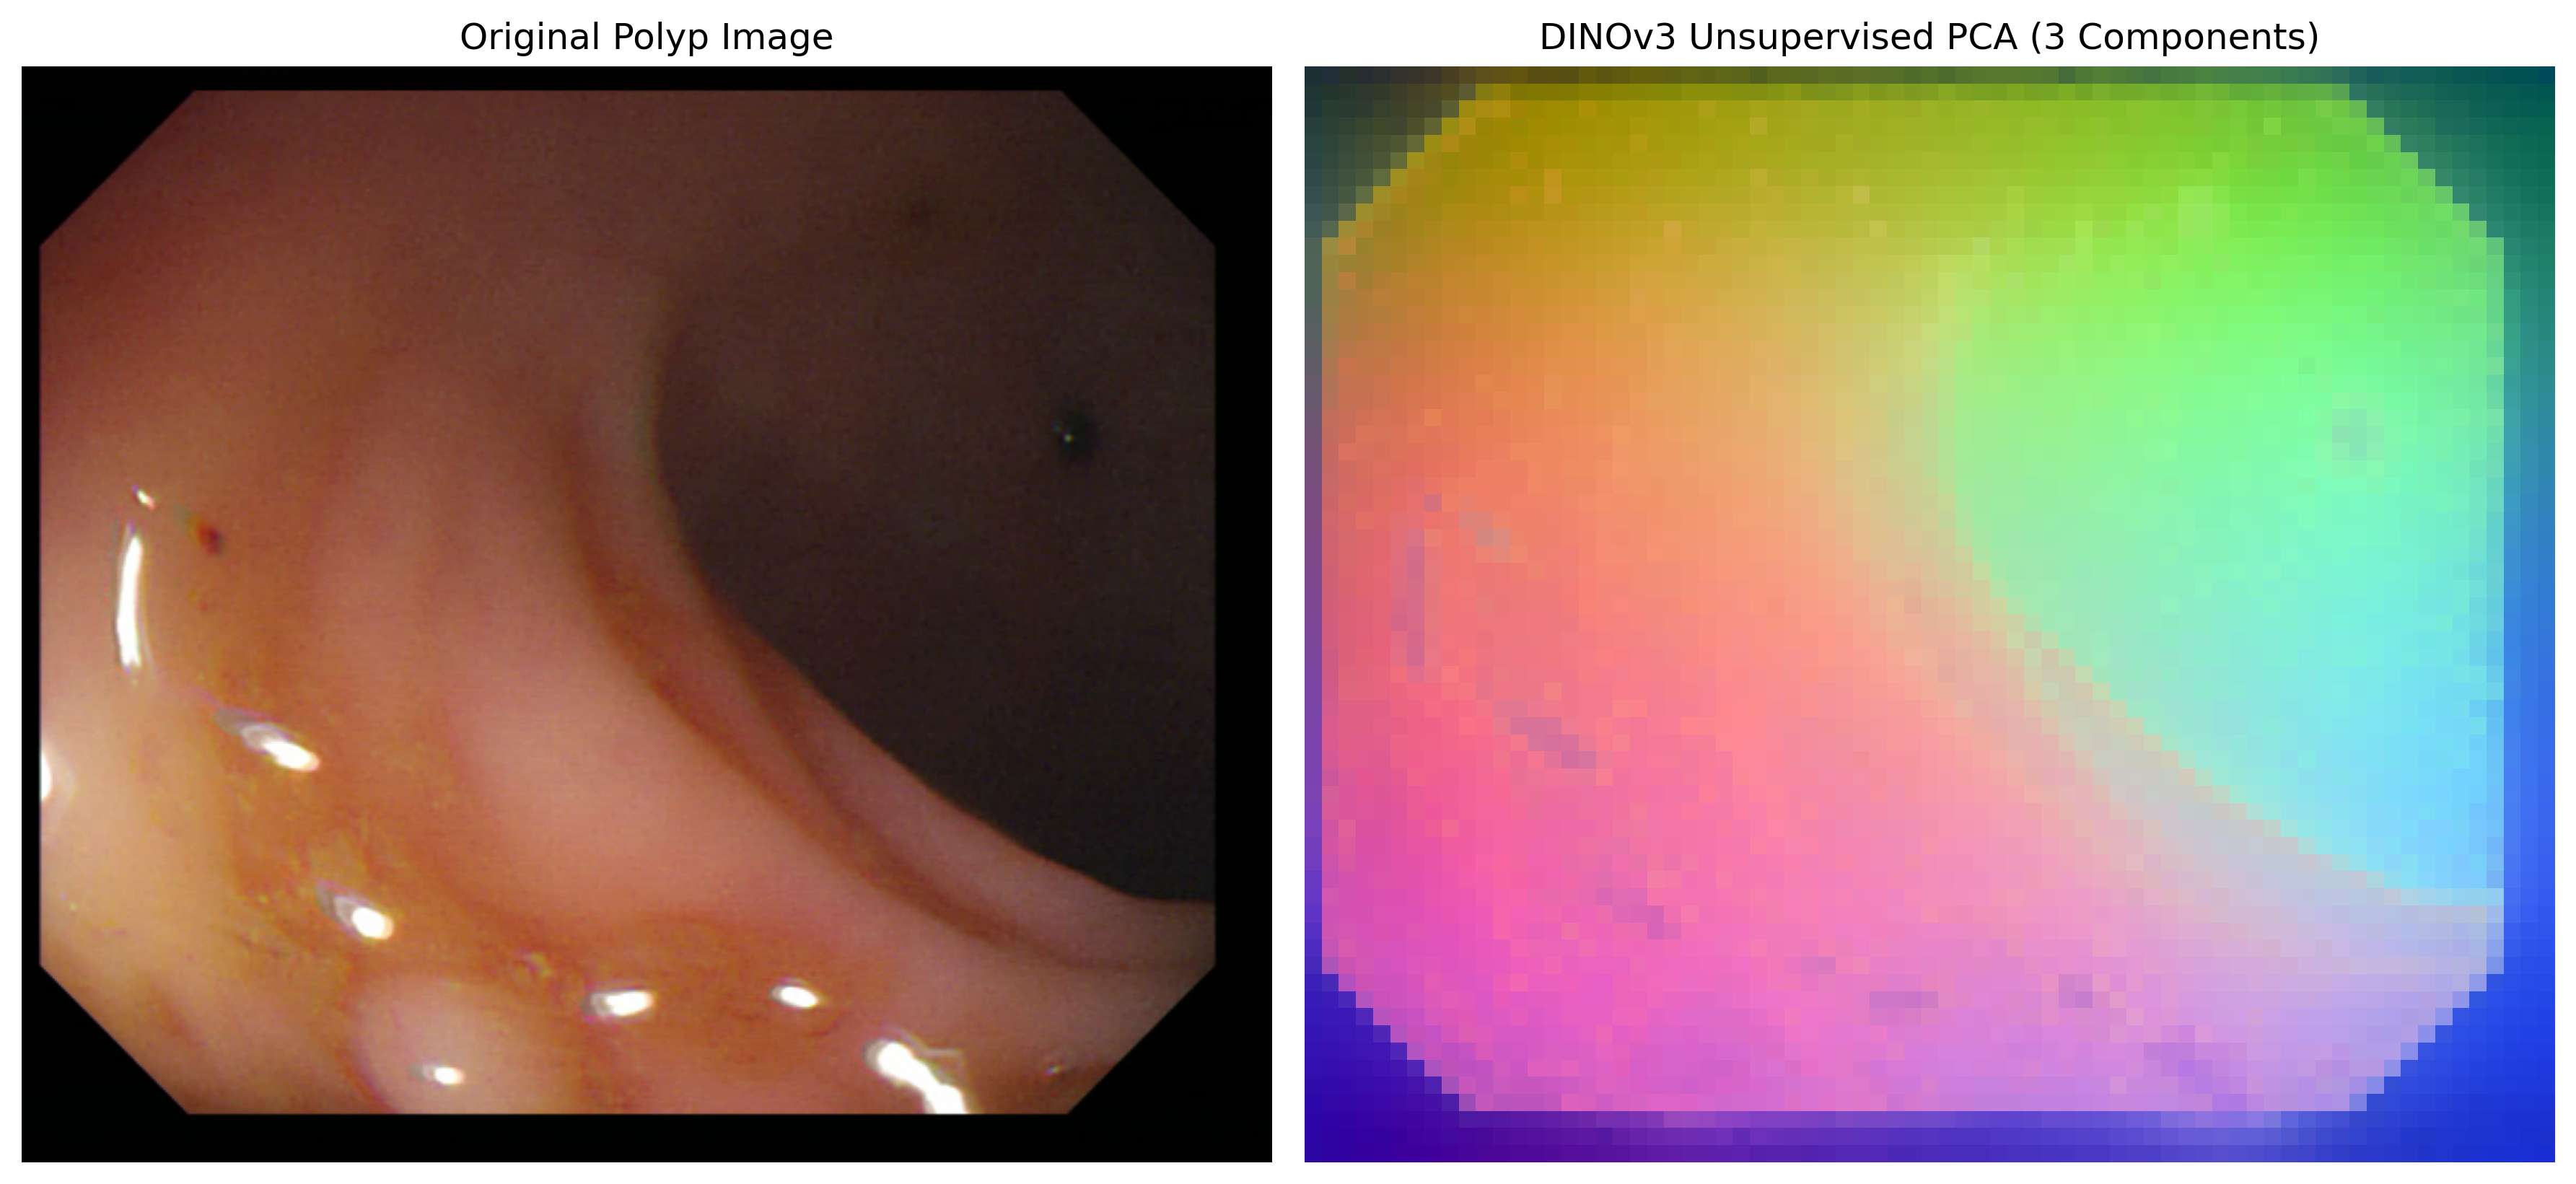

In [6]:
import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# ==========================================
# 1. 參數設定與模型載入
# ==========================================
PATCH_SIZE = 16
IMAGE_SIZE = 1024  # 建議使用較大的解析度以獲得更細緻的邊界
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# 請修改為您的本地路徑
CUSTOM_WEIGHT_PATH = "/home/U116med/wch_code/dino_v3/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth"
LOCAL_IMAGE_PATH = "/home/U116med/data/polyp/TestDataset/test/images/10CVC-ColonDB.png"

print("正在載入 DINOv3 模型...")
model = torch.hub.load('facebookresearch/dinov3', 'dinov3_vits16plus', source='github', pretrained=False)
model.load_state_dict(torch.load(CUSTOM_WEIGHT_PATH, map_location="cpu"), strict=True)
model.cuda().eval()

# ==========================================
# 2. 影像讀取與前處理
# ==========================================
if not os.path.exists(LOCAL_IMAGE_PATH):
    raise FileNotFoundError(f"找不到指定的影像檔案: {LOCAL_IMAGE_PATH}")

image = Image.open(LOCAL_IMAGE_PATH).convert("RGB")
w, h = image.size
h_patches = int(IMAGE_SIZE / PATCH_SIZE)
w_patches = int((w * IMAGE_SIZE) / (h * PATCH_SIZE))

# 確保長寬能被 Patch Size 整除
image_resized = TF.to_tensor(TF.resize(image, (h_patches * PATCH_SIZE, w_patches * PATCH_SIZE)))
image_resized_norm = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

# ==========================================
# 3. 提取 DINOv3 空間特徵 (全圖)
# ==========================================
print("正在提取特徵...")
with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        # n=1 代表只取最後一層的輸出
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0).cuda(), n=1, reshape=True, norm=True)
        
        # 取出特徵並移除 Batch 維度: shape (384, h_patches, w_patches)
        x = feats[0].squeeze(0).cpu()
        
        # 將維度展平為 (Token數, 384)，以符合 PCA 的輸入格式
        c, hp, wp = x.shape
        x_flat = x.view(c, -1).permute(1, 0).numpy() # shape: (hp*wp, 384)

# ==========================================
# 4. 執行整圖 PCA 降維 (384D -> 3D)
# ==========================================
print("正在執行 PCA 降維...")
pca = PCA(n_components=3)
pca_features = pca.fit_transform(x_flat) # shape: (hp*wp, 3)

# 為了將 3 個主成分映射為 RGB 影像，我們需要將數值標準化到 0~1 之間
# 使用 Min-Max Scaling 確保顏色對比度最大化
pca_features_min = pca_features.min(axis=0)
pca_features_max = pca_features.max(axis=0)
pca_features_normalized = (pca_features - pca_features_min) / (pca_features_max - pca_features_min)

# 重塑回二維空間的影像格式 (H, W, 3)
pca_image = pca_features_normalized.reshape(hp, wp, 3)

# ==========================================
# 5. 視覺化對比
# ==========================================
plt.figure(figsize=(12, 6), dpi=300)

plt.subplot(1, 2, 1)
plt.imshow(image_resized.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title("Original Polyp Image")

plt.subplot(1, 2, 2)
plt.imshow(pca_image)
plt.axis('off')
plt.title("DINOv3 Unsupervised PCA (3 Components)")

plt.tight_layout()
plt.show()